# 02 — Split-Conformal Calibration of RUL Intervals

**FusionCore v2 — Phase Ph-v2.1**

Split conformal prediction (Vovk *et al.* 2005; Lei *et al.* 2018; Angelopoulos
& Bates 2023) is a **distribution-free** method to wrap any RUL regressor with
calibrated prediction intervals.

### Procedure

1. Cut Internal Validation 50 / 50 (RNG 42) into:
   - **Calibration slice** (~15,500 windows) — used to compute residual quantiles
   - **Evaluation slice** (~15,500 windows) — sanity-check coverage on held-out data
2. For each calibration window, compute the absolute residual $r_i = |y_i - \hat{y}_i|$
3. The empirical $(1 - \alpha)$-quantile of $\{r_i\}$ — call it $\hat{q}_{1-\alpha}$ — is the half-width of the prediction interval
4. At inference time, the interval for a new prediction $\hat{y}$ is $[\hat{y} - \hat{q}, \hat{y} + \hat{q}]$, clipped to $[0, R_{\text{cap}}]$

### Marginal coverage guarantee

For exchangeable data: $\mathbb{P}(y_{\text{new}} \in [\hat{y} - \hat{q}, \hat{y} + \hat{q}]) \geq 1 - \alpha$.
The guarantee is **marginal** — it holds on average across all test points, not conditionally on any subgroup. We therefore additionally report per-subset and per-risk-band coverage as informational diagnostics.

### Outputs (under `v2/outputs/`)

| File | Purpose |
|---|---|
| `phase_v2_1_conformal.pkl` | Dict {α → q̂} for α ∈ {0.05, 0.10, 0.20} |
| `phase_v2_1_calibration_metadata.json` | Slice indices (RNG-reproducible), per-α empirical coverage on cal & eval slices |
| `phase_v2_1_residual_distribution.png` | Calibration residual histogram with chosen α quantiles annotated |

### References
- Vovk, V., Gammerman, A. and Shafer, G. (2005). *Algorithmic Learning in a Random World*. Springer.
- Lei, J. *et al.* (2018). Distribution-free predictive inference for regression. *JASA* 113(523).
- Angelopoulos, A. N. and Bates, S. (2023). Conformal prediction: a gentle introduction. *Foundations and Trends in Machine Learning* 16(4).

## Cell 1 — Imports

In [1]:
# ============================================================================
# Cell 1 — Imports
# ============================================================================
import sys, os, json, warnings, pickle, time
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import matplotlib as mpl
warnings.filterwarnings("ignore")
print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")

Python  : 3.13.13
PyTorch : 2.11.0


## Cell 2 — Palette and Constants

In [2]:
# ============================================================================
# Cell 2 — Palette
# ============================================================================
FC_DARK_BLUE  = "#0D1B2A"; FC_NAVY = "#1B3A5C"; FC_ORANGE = "#D96A1B"
FC_DEEP_RED   = "#9B1B30"; FC_STEEL = "#4A6274"; FC_CHARCOAL = "#2D2D2D"
FC_LIGHT_GREY = "#E8E8E8"
FC_PALETTE = [FC_DARK_BLUE, FC_ORANGE, FC_DEEP_RED, FC_STEEL, FC_NAVY]
plt.rcParams.update({
    "figure.figsize":(14,5), "figure.dpi":110, "savefig.dpi":300, "savefig.bbox":"tight",
    "font.family":"serif", "font.size":11,
    "axes.titlesize":13, "axes.titleweight":"bold", "axes.labelsize":11,
    "axes.edgecolor":FC_CHARCOAL, "axes.labelcolor":FC_CHARCOAL,
    "axes.spines.top":False, "axes.spines.right":False,
    "axes.prop_cycle":mpl.cycler(color=FC_PALETTE),
    "xtick.color":FC_CHARCOAL, "ytick.color":FC_CHARCOAL,
    "legend.fontsize":9, "legend.framealpha":0.9,
    "grid.color":FC_LIGHT_GREY, "grid.alpha":0.6, "grid.linestyle":":",
})
print("Palette configured.")

Palette configured.


In [3]:
# ============================================================================
# Cell 3 — Project Constants
# ============================================================================
PROJECT_ROOT = Path("/Users/michelemaestrini/Desktop/PiNet/FusionCore")
V1_OUT       = PROJECT_ROOT / "v1" / "outputs"
V2_OUT       = PROJECT_ROOT / "v2" / "outputs"

W = 30; N_FEATURES = 89; N_PHYSICS_TOKENS = 11
TCN_HIDDEN = 64; TCN_KERNEL = 3; TCN_DILATIONS = [1,2,4,8,16]; TCN_DROPOUT = 0.25
EMBED_DIM = 128; PHYS_HIDDEN = 50; PHYS_OUT = 32; HEAD_HIDDEN = 64
N_RISK_CLASSES = 3; RUL_CAP = 125; BATCH_SIZE = 64

CONFORMAL_ALPHAS = (0.05, 0.10, 0.20)
CALIBRATION_FRACTION = 0.50

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
print(f"Device : {DEVICE}    α targets : {CONFORMAL_ALPHAS}")

Device : mps    α targets : (0.05, 0.1, 0.2)


---

## Part A — PiNet (re-defined inline)

In [4]:
# ============================================================================
# Cell 4 — PiNet Architecture
# ============================================================================
class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation):
        super().__init__()
        self.left_pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, padding=0, dilation=dilation)
    def forward(self, x): return self.conv(F.pad(x, (self.left_pad, 0)))

class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        self.conv1 = CausalConv1d(in_ch, out_ch, kernel_size, dilation)
        self.norm1 = nn.LayerNorm(out_ch)
        self.conv2 = CausalConv1d(out_ch, out_ch, kernel_size, dilation)
        self.norm2 = nn.LayerNorm(out_ch)
        self.dropout = nn.Dropout(dropout)
        self.shortcut = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        residual = self.shortcut(x)
        h = self.conv1(x); h = self.norm1(h.transpose(1,2)).transpose(1,2)
        h = F.relu(h); h = self.dropout(h)
        h = self.conv2(h); h = self.norm2(h.transpose(1,2)).transpose(1,2)
        h = h + residual; h = F.relu(h); h = self.dropout(h)
        return h

class TCN(nn.Module):
    def __init__(self):
        super().__init__()
        layers, ic = [], N_FEATURES
        for d in TCN_DILATIONS:
            layers.append(TemporalBlock(ic, TCN_HIDDEN, TCN_KERNEL, d, TCN_DROPOUT))
            ic = TCN_HIDDEN
        self.network = nn.Sequential(*layers)
    def forward(self, x): return self.network(x.transpose(1,2)).transpose(1,2)

class PhysicsMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(N_PHYSICS_TOKENS, PHYS_HIDDEN), nn.BatchNorm1d(PHYS_HIDDEN), nn.ReLU(),
            nn.Linear(PHYS_HIDDEN, PHYS_OUT), nn.BatchNorm1d(PHYS_OUT), nn.ReLU(),
        )
    def forward(self, x_phys, regime_w):
        return self.net(torch.cat([x_phys[:, -1, :], regime_w.unsqueeze(-1)], dim=-1))

class FusionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        ind = TCN_HIDDEN*2 + PHYS_OUT
        h = (ind + EMBED_DIM)//2
        self.net = nn.Sequential(
            nn.Linear(ind, h), nn.LayerNorm(h), nn.ReLU(),
            nn.Linear(h, EMBED_DIM), nn.LayerNorm(EMBED_DIM), nn.ReLU(),
        )
    def forward(self, x): return self.net(x)

class RULHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(EMBED_DIM, HEAD_HIDDEN), nn.ReLU(),
                                 nn.Linear(HEAD_HIDDEN, 1))
    def forward(self, x): return self.net(x).squeeze(-1)

class RiskBandHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(EMBED_DIM, HEAD_HIDDEN), nn.ReLU(),
                                 nn.Linear(HEAD_HIDDEN, N_RISK_CLASSES))
    def forward(self, x): return self.net(x)

class PiNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.tcn=TCN(); self.physics=PhysicsMLP(); self.fusion=FusionMLP()
        self.rul_head=RULHead(); self.risk_head=RiskBandHead()
    @staticmethod
    def _masked_mean(h, mask):
        m = mask.float().unsqueeze(-1)
        return (h*m).sum(dim=1) / m.sum(dim=1).clamp(min=1.0)
    def forward(self, x_tcn, x_phys, mask, regime_w):
        h        = self.tcn(x_tcn)
        last_h   = h[:, -1, :]
        mean_h   = self._masked_mean(h, mask)
        tcn_out  = torch.cat([last_h, mean_h], dim=-1)
        phys_out = self.physics(x_phys, regime_w)
        embed    = self.fusion(torch.cat([tcn_out, phys_out], dim=-1))
        return {"rul_pred":self.rul_head(embed),
                "risk_logits":self.risk_head(embed),
                "embed":embed}
print("PiNet defined.")

PiNet defined.


In [5]:
# ============================================================================
# Cell 5 — Load Best Checkpoint (Stage B preferred, Stage A fallback)
# ============================================================================
stage_b_path = V2_OUT / "phase_v2_0_pinet_stage_b_best.pt"
stage_a_path = V1_OUT / "phase_v1_3_pinet_best.pt"
init_path    = V1_OUT / "phase_v1_2_pinet_init.pt"

pinet = PiNet().to(DEVICE)
SMOKE_MODE = False
provenance = ""
if stage_b_path.exists():
    state = torch.load(stage_b_path, map_location=DEVICE, weights_only=True)
    provenance = "v2 Stage B"
elif stage_a_path.exists():
    state = torch.load(stage_a_path, map_location=DEVICE, weights_only=True)
    provenance = "v1 Stage A (FALLBACK — Stage B not yet trained)"
    SMOKE_MODE = True
else:
    state = torch.load(init_path, map_location=DEVICE, weights_only=True)
    provenance = "v1.2 init (SMOKE — no trained model available)"
    SMOKE_MODE = True
pinet.load_state_dict(state)
pinet.eval()
print(f"Loaded PiNet: {provenance}")

Loaded PiNet: v2 Stage B


---

## Part B — Split Internal Val 50 / 50 into Calibration and Evaluation Slices

In [6]:
# ============================================================================
# Cell 6 — Load Internal Val and Build the 50/50 Split
# ============================================================================
val_bundle = torch.load(V1_OUT / "windows_val.pt", weights_only=False)
Xw_val   = val_bundle["Xw"]
mask_val = val_bundle["mask"]
rul_val  = val_bundle["rul"]
rb_val   = val_bundle["risk_band"]
rw_val   = val_bundle["regime_w"]
mw_val   = val_bundle["meta"]
phys_idx = torch.load(V1_OUT / "windows_train.pt", weights_only=False)["phys_idx"]

n_val = len(rul_val)
rng = np.random.default_rng(RANDOM_STATE)
perm = rng.permutation(n_val)
n_cal = int(round(CALIBRATION_FRACTION * n_val))
cal_idx  = np.sort(perm[:n_cal])
eval_idx = np.sort(perm[n_cal:])
print(f"Internal Val total : {n_val:,}")
print(f"Calibration slice  : {len(cal_idx):,} windows")
print(f"Evaluation slice   : {len(eval_idx):,} windows")

Internal Val total : 31,028
Calibration slice  : 15,514 windows
Evaluation slice   : 15,514 windows


In [7]:
# ============================================================================
# Cell 7 — Inference on Calibration and Evaluation Slices
# ============================================================================
class _DS(Dataset):
    def __init__(s, Xw, mk, rul, rb, rw, pi, idx):
        s.Xw, s.mk, s.rul, s.rb, s.rw, s.pi = Xw, mk, rul, rb, rw, pi
        s.idx = torch.from_numpy(np.asarray(idx, dtype=np.int64))
    def __len__(s): return len(s.idx)
    def __getitem__(s, i):
        j = int(s.idx[i]); x = s.Xw[j]
        return {"x_tcn":x, "x_phys":x.index_select(-1, s.pi),
                "mask":s.mk[j], "rul":s.rul[j], "risk_band":s.rb[j], "regime_w":s.rw[j]}

ds_cal  = _DS(Xw_val, mask_val, rul_val, rb_val, rw_val, phys_idx, cal_idx)
ds_eval = _DS(Xw_val, mask_val, rul_val, rb_val, rw_val, phys_idx, eval_idx)
dl_cal  = DataLoader(ds_cal,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
dl_eval = DataLoader(ds_eval, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

@torch.no_grad()
def infer_rul(model, loader):
    model.eval()
    rp_a, rt_a, rb_a, rgw_a = [], [], [], []
    for batch in loader:
        bd = {k:v.to(DEVICE, non_blocking=True) for k,v in batch.items()}
        out = model(bd["x_tcn"], bd["x_phys"], bd["mask"], bd["regime_w"])
        rp_a.append(out["rul_pred"].cpu().numpy())
        rt_a.append(bd["rul"].cpu().numpy())
        rb_a.append(bd["risk_band"].cpu().numpy())
        rgw_a.append(bd["regime_w"].cpu().numpy())
    return (np.concatenate(rp_a).clip(0, RUL_CAP),
            np.concatenate(rt_a),
            np.concatenate(rb_a),
            np.concatenate(rgw_a))

t0 = time.time()
rp_cal,  rt_cal,  rb_cal,  _ = infer_rul(pinet, dl_cal)
rp_eval, rt_eval, rb_eval, _ = infer_rul(pinet, dl_eval)
print(f"Calibration inference : {len(rp_cal):,} preds  ({time.time()-t0:.1f}s)")
print(f"Evaluation  inference : {len(rp_eval):,} preds")

Calibration inference : 15,514 preds  (2.5s)
Evaluation  inference : 15,514 preds


---

## Part C — Compute Conformal Quantiles

In [8]:
# ============================================================================
# Cell 8 — Calibration Residuals and Per-α Quantiles
# ============================================================================
res_cal  = np.abs(rp_cal  - rt_cal)
res_eval = np.abs(rp_eval - rt_eval)

# Finite-sample correction (Lei et al. 2018, Eq. 4): use ceil((n+1)(1-α))/n quantile.
n_cal = len(res_cal)
def split_conformal_quantile(residuals, alpha, n):
    k = int(np.ceil((n + 1) * (1.0 - alpha)))
    k = min(max(k, 1), n)
    return float(np.sort(residuals)[k - 1])

quantiles = {alpha: split_conformal_quantile(res_cal, alpha, n_cal)
             for alpha in CONFORMAL_ALPHAS}
print(f"Calibration residuals: n = {n_cal}, mean = {res_cal.mean():.3f}, median = {np.median(res_cal):.3f}")
print()
print(f"{'α':>5}    {'(1-α)':>5}    {'q̂':>8}    [-q̂, +q̂] half-width")
for a in CONFORMAL_ALPHAS:
    print(f"{a:>5.2f}    {1-a:>5.2f}    {quantiles[a]:>8.3f}")
joblib.dump(quantiles, V2_OUT / "phase_v2_1_conformal.pkl")
print(f"\nSaved {V2_OUT / 'phase_v2_1_conformal.pkl'}")

Calibration residuals: n = 15514, mean = 10.501, median = 7.335

    α    (1-α)          q̂    [-q̂, +q̂] half-width
 0.05     0.95      31.535
 0.10     0.90      25.207
 0.20     0.80      18.280

Saved /Users/michelemaestrini/Desktop/PiNet/FusionCore/v2/outputs/phase_v2_1_conformal.pkl


In [9]:
# ============================================================================
# Cell 9 — Empirical Coverage on Calibration and Evaluation Slices
# ============================================================================
def coverage(rul_pred, rul_true, q):
    lo = np.maximum(0.0, rul_pred - q)
    hi = np.minimum(float(RUL_CAP), rul_pred + q)
    return float(np.mean((rul_true >= lo) & (rul_true <= hi)))

cov_cal_table = {}
cov_eval_table = {}
print(f"{'α':>5}    {'nominal':>7}    {'cov_cal':>7}    {'cov_eval':>7}")
for a in CONFORMAL_ALPHAS:
    q = quantiles[a]
    cc = coverage(rp_cal, rt_cal, q)
    ce = coverage(rp_eval, rt_eval, q)
    cov_cal_table[a] = cc
    cov_eval_table[a] = ce
    print(f"{a:>5.2f}    {1-a:>7.2f}    {cc:>7.4f}    {ce:>7.4f}")

    α    nominal    cov_cal    cov_eval
 0.05       0.95     0.9501     0.9475
 0.10       0.90     0.9001     0.8986
 0.20       0.80     0.8001     0.7983


In [10]:
# ============================================================================
# Cell 10 — Per-Risk-Band Coverage on Evaluation Slice (informational)
# ============================================================================
band_names = ["Healthy","Warning","Critical"]
print(f"Per-band coverage on evaluation slice:")
print(f"{'α':>5}    {'H':>7}    {'W':>7}    {'C':>7}")
per_band_cov = {a: {} for a in CONFORMAL_ALPHAS}
for a in CONFORMAL_ALPHAS:
    q = quantiles[a]
    cov_per_band = []
    for b in (0,1,2):
        m = (rb_eval == b)
        if m.sum() == 0:
            cov_per_band.append(float("nan")); continue
        c = coverage(rp_eval[m], rt_eval[m], q)
        cov_per_band.append(c)
        per_band_cov[a][band_names[b]] = c
    print(f"{a:>5.2f}    " + "    ".join(f"{c:>7.4f}" for c in cov_per_band))

Per-band coverage on evaluation slice:
    α          H          W          C
 0.05     0.9356     0.9490     1.0000
 0.10     0.8708     0.9153     0.9995
 0.20     0.7604     0.8306     0.9201


In [11]:
# ============================================================================
# Cell 11 — Persist Calibration Metadata
# ============================================================================
metadata = {
    "smoke_mode":           SMOKE_MODE,
    "pinet_provenance":     provenance,
    "calibration_fraction": CALIBRATION_FRACTION,
    "random_state":         RANDOM_STATE,
    "n_val":                int(n_val),
    "n_calibration":        int(len(cal_idx)),
    "n_evaluation":         int(len(eval_idx)),
    "calibration_indices":  cal_idx.tolist(),
    "evaluation_indices":   eval_idx.tolist(),
    "alphas":               list(CONFORMAL_ALPHAS),
    "quantiles":            {str(a): float(q) for a, q in quantiles.items()},
    "coverage_calibration": {str(a): float(c) for a, c in cov_cal_table.items()},
    "coverage_evaluation":  {str(a): float(c) for a, c in cov_eval_table.items()},
    "per_band_coverage_evaluation": {str(a): {k: float(v) for k,v in d.items()}
                                      for a, d in per_band_cov.items()},
    "calibration_residuals_summary": {
        "mean":     float(res_cal.mean()),
        "median":   float(np.median(res_cal)),
        "std":      float(res_cal.std()),
        "max":      float(res_cal.max()),
    },
}
with open(V2_OUT / "phase_v2_1_calibration_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Saved {V2_OUT / 'phase_v2_1_calibration_metadata.json'}")

Saved /Users/michelemaestrini/Desktop/PiNet/FusionCore/v2/outputs/phase_v2_1_calibration_metadata.json


---

## Part D — Visualisation

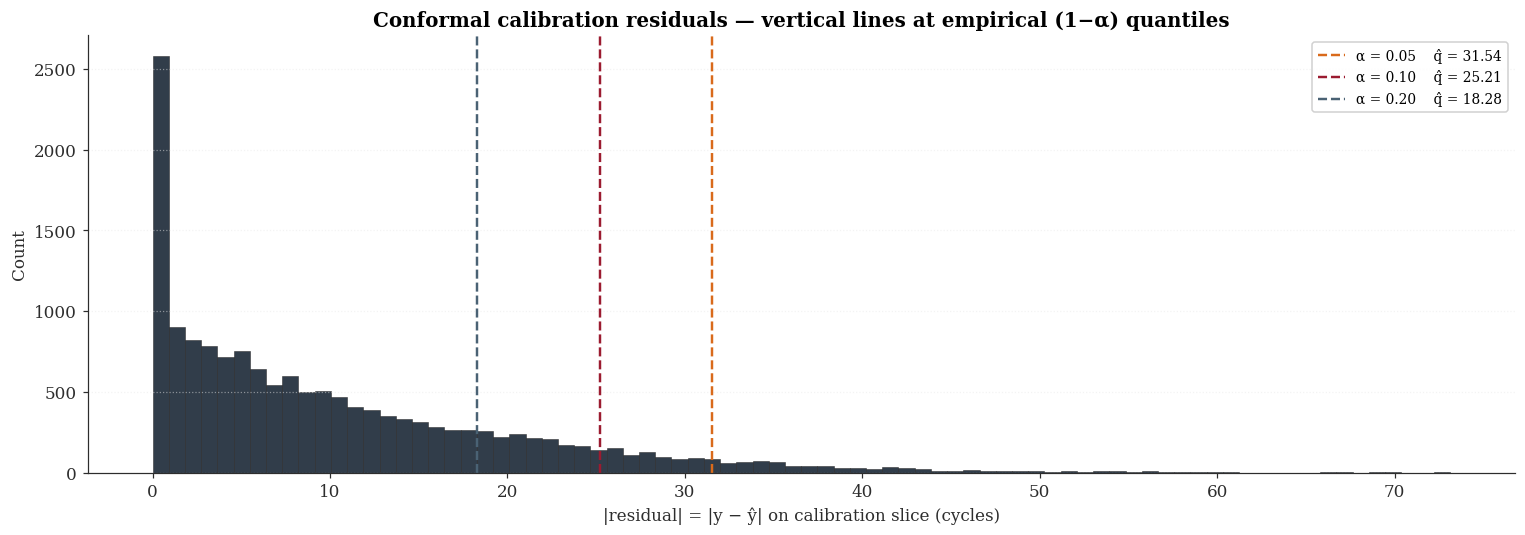

In [12]:
# ============================================================================
# Cell 12 — Visual: Calibration Residual Distribution with α Quantiles
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(res_cal, bins=80, color=FC_DARK_BLUE, alpha=0.85, edgecolor=FC_CHARCOAL,
        linewidth=0.4)
qcols = [FC_ORANGE, FC_DEEP_RED, FC_STEEL]
for (a, q), col in zip(sorted(quantiles.items()), qcols):
    ax.axvline(q, color=col, linewidth=1.6, linestyle="--",
               label=f"α = {a:.2f}    q̂ = {q:.2f}")
ax.set_xlabel("|residual| = |y − ŷ| on calibration slice (cycles)")
ax.set_ylabel("Count")
ax.set_title("Conformal calibration residuals — vertical lines at empirical (1−α) quantiles")
ax.legend()
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(V2_OUT / "phase_v2_1_residual_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

---

## Ph-v2.1 Gate

In [13]:
# ============================================================================
# Cell 13 — Ph-v2.1 Gate
# ============================================================================
print("="*78); print("  Ph-v2.1 GATE — Split-Conformal Calibration"); print("="*78)
checks = []
checks.append(("Calibration slice non-empty (≥ 1000)",
               len(cal_idx) >= 1000, f"{len(cal_idx)} windows"))
checks.append(("Evaluation slice non-empty (≥ 1000)",
               len(eval_idx) >= 1000, f"{len(eval_idx)} windows"))
checks.append(("All inferred predictions finite",
               np.isfinite(rp_cal).all() and np.isfinite(rp_eval).all(), "all finite"))
for a in CONFORMAL_ALPHAS:
    checks.append((f"q̂ for α = {a:.2f} is finite & positive",
                   np.isfinite(quantiles[a]) and quantiles[a] > 0,
                   f"q̂ = {quantiles[a]:.3f}"))
for a in CONFORMAL_ALPHAS:
    cc = cov_cal_table[a]
    nominal = 1 - a
    checks.append((f"Cal coverage at α = {a:.2f} within ±2% of nominal {nominal:.2f}",
                   abs(cc - nominal) <= 0.02, f"cov_cal = {cc:.4f}"))
checks.append(("Persisted: phase_v2_1_conformal.pkl",
               (V2_OUT / "phase_v2_1_conformal.pkl").exists(), "OK"))
checks.append(("Persisted: phase_v2_1_calibration_metadata.json",
               (V2_OUT / "phase_v2_1_calibration_metadata.json").exists(), "OK"))
checks.append(("Persisted: phase_v2_1_residual_distribution.png",
               (V2_OUT / "phase_v2_1_residual_distribution.png").exists(), "OK"))

# Round-trip pickle.
try:
    q_loaded = joblib.load(V2_OUT / "phase_v2_1_conformal.pkl")
    rt_ok = (sorted(q_loaded.keys()) == sorted(quantiles.keys()) and
             all(abs(q_loaded[a] - quantiles[a]) < 1e-9 for a in quantiles))
except Exception:
    rt_ok = False
checks.append(("Quantile artefact round-trips via joblib", rt_ok, "OK"))

for desc, ok, detail in checks:
    flag = "PASS" if ok else "FAIL"
    print(f"  [{flag}] {desc:<60s} {detail}")
n_pass = sum(1 for _,o,_ in checks if o)
print(f"\n  Ph-v2.1 GATE: {n_pass}/{len(checks)} PASS")
if not all(o for _,o,_ in checks):
    fails = [d for d, o, _ in checks if not o]
    print(f"\n  FAILING checks ({len(fails)}):")
    for f in fails:
        print(f"    - {f}")
assert all(o for _,o,_ in checks), "Ph-v2.1 GATE FAILED"
if SMOKE_MODE:
    print("  SMOKE MODE — re-run after Stage B (Ph-v2.0) for valid intervals.")
print("  Ph-v2.1 — proceed to Ph-v2.2 (temperature scaling)")

  Ph-v2.1 GATE — Split-Conformal Calibration
  [PASS] Calibration slice non-empty (≥ 1000)                         15514 windows
  [PASS] Evaluation slice non-empty (≥ 1000)                          15514 windows
  [PASS] All inferred predictions finite                              all finite
  [PASS] q̂ for α = 0.05 is finite & positive                         q̂ = 31.535
  [PASS] q̂ for α = 0.10 is finite & positive                         q̂ = 25.207
  [PASS] q̂ for α = 0.20 is finite & positive                         q̂ = 18.280
  [PASS] Cal coverage at α = 0.05 within ±2% of nominal 0.95          cov_cal = 0.9501
  [PASS] Cal coverage at α = 0.10 within ±2% of nominal 0.90          cov_cal = 0.9001
  [PASS] Cal coverage at α = 0.20 within ±2% of nominal 0.80          cov_cal = 0.8001
  [PASS] Persisted: phase_v2_1_conformal.pkl                          OK
  [PASS] Persisted: phase_v2_1_calibration_metadata.json              OK
  [PASS] Persisted: phase_v2_1_residual_distribution.

---

## Summary

### Ph-v2.1 outputs
- `phase_v2_1_conformal.pkl` — quantiles per α
- `phase_v2_1_calibration_metadata.json` — full provenance + coverage diagnostics
- `phase_v2_1_residual_distribution.png`

### Next notebook
`03_Temperature_Scaling.ipynb` — calibrate the risk-band softmax temperature on the same calibration slice (this preserves the disjoint role separation: calibration slice is for both conformal RUL quantile fitting and risk-band temperature fitting; evaluation slice is held-out for diagnostics in both notebooks).